In [1]:
"""
LDA PIPELINE -- ALL-SESSIONS VARIANT
====================================
A copy of LDA_analyses_pipeline_CORRECTED with two changes, both about WHICH
sessions define things. Everything else is identical.

1. BALANCED SUBSAMPLING KEEPS EVERY MOUSE (cells with `balanced_idx`).
   The original rule was
       if len(m_idx) >= cap: rng.choice(m_idx, cap)
   which dropped a mouse with fewer sessions than the cap out of the TRAINING set
   while still TESTING it -- against a classifier that had never seen it, so those
   folds were guaranteed misses. Because the guard is evaluated after leave-one-out,
   a mouse fell below it precisely in the folds where it was the test item. With 20
   of 58 mice having exactly 3 sessions, n_per_mouse=4 turned 22% of folds into
   automatic errors and accuracy dropped for that reason alone. The cap is now a
   maximum contribution rather than a minimum requirement:
       take = min(cap, len(m_idx))
   Measured effect: n_per_mouse 3 / 4 / 5 gives 0.770 / 0.651 / 0.480 under the old
   rule and 0.770 / 0.814 / 0.848 under this one -- monotone, as expected.

2. THE SAVED EMBEDDING IS FIT ON ALL SESSIONS (the `final_transformed` cell).
   It used to be fit on whatever X_train the loop above happened to leave behind --
   one arbitrary balanced draw from the last fold. That made the saved embedding
   irreproducible: two draws under the same rule give LD1 axes correlating anywhere
   from 0.05 to 0.85, because the leading LDA eigenvalues are near-degenerate
   (0.267 vs 0.253) and each draw picks a different rotation within the same
   subspace. Fitting on every session is deterministic (two refits give |rho| = 1.0).

   KNOWN LIMITATION of change 2: sessions per mouse are unequal (3 to 16), so mice
   with more sessions weigh more in the pooled within-class scatter, and mice with
   fewer get noisier -- therefore more extreme -- class means. Set EMBED_BALANCED to
   True to fit the embedding on one balanced draw per mouse instead (reproducible via
   EMBED_SEED, but back to depending on a draw).
"""
EMBED_BALANCED = False     # False = fit the embedding on all sessions
EMBED_SEED = 0             # only used when EMBED_BALANCED is True

# ---- SHARED FIGURE STYLE ----------------------------------------------------
# paper-individuality/paper_style.py holds every cross-figure decision: which colour
# a timepoint is, what LD1's gradient looks like, panel sizes, where figures are
# written. Run this BEFORE the imports cell, which does an os.chdir.
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / 'learning_individuality'))   # session_filters lives there
import importlib
import paper_style
importlib.reload(paper_style)   # kernels cache modules: without this, edits to
ps = paper_style                # paper_style stay invisible until a restart
ps.use('poster')      # 'poster' = big type for a poster; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

# Individuality dimensions with LDA

In [2]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [3]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# --Machine learning and statistics

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import umap
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from statsmodels.distributions.empirical_distribution import ECDF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats
from sklearn.metrics import f1_score
from scipy.stats import zscore

# Get my functions
from functions import get_metadata
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette

from one.api import ONE
one = ONE(mode='remote')

In [4]:
""" IMPORTANT PATHS """
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'
base_path = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/'

## Load sequence data

In [5]:
n_paw_states = 8

# Explicit filenames per data type -- add/remove/comment entries to control which data types
# are loaded and combined into the final design matrix (previously done by commenting/
# uncommenting a single `filename` variable below). Fill in the paths you want to use.
data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'all_trials_04-05-2026',
}

data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'session_trial_meta_10-07-2026',
}
data_files = {
    # 'syllables': base_path + '8_k_10_bin_syllables_06-07-2026',
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    # 'trial': base_path + 'session_trial_meta_10-07-2026',
}

data_files = {
    # 'syllables': base_path + '8_k_10_bin_syllables_06-07-2026',
    'syllables': base_path + '8_k_10_bin_syllables_19-08-2026',
    # 'syllables': base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    # 'trial': base_path + 'session_trial_meta_10-07-2026',
}


### Filter data

In [6]:
""" SESSION EXCLUSIONS -- from the curated QC sheet, not a hardcoded list.

Same logic as the learning_individuality scripts: session_filters reads
individuality-paper_data_4Sep26.csv (now under paper-individuality/data/, found
wherever it lives by session_filters.find_csv) and returns the eids whose
`Used in paper` column says to drop them. Changing the sheet changes every analysis
at once, and the two folders can no longer drift apart.

  QC_STRICTNESS 'filtered_out'            -> drop Used in paper == 'filtered out'
                'filtered_out_and_revise' -> drop those PLUS 'need to revise'

This pipeline only reads the proficient (recording) file, so it takes the Proficient
exclusions. The previous hardcoded list of 3 eids is still in
LDA_analyses_pipeline_CORRECTED.ipynb if you need to compare.
"""
# A long-lived kernel caches imported modules, so edits to session_filters -- or
# the QC sheet moving folders -- stay invisible until a restart. Reload explicitly.
import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint, find_csv

QC_STRICTNESS = 'filtered_out'
_excl = exclusions_by_timepoint(QC_STRICTNESS)
prob_sessions = sorted(_excl['Proficient'])
print(f"QC sheet: {find_csv()}")
print(f"exclusions ({QC_STRICTNESS}): "
      + ", ".join(f"{k} {len(v)}" for k, v in _excl.items())
      + f"  ->  {len(prob_sessions)} proficient sessions dropped")  # Ago 7 2026

# f3eeb2d4-87ce-49ae-8a74-21665f6f1536



def filter_sequences(all_sequences):
    print(str(len(all_sequences.mouse_name.unique())) + str(' mice in total'))
    print(str(len(all_sequences.session.unique())) + str(' sessions in total'))

    # FIX: Use drop=True to avoid creating 'index' column
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    print(str(len(all_sequences['session'].unique())) + str(' sessions after removing bad sessions'))

    # Filter out mice without enough sessions
    session_count = all_sequences[['mouse_name', 'session']].drop_duplicates().groupby(['mouse_name'])['session'].count().reset_index()
    multi_sess_mice = session_count.loc[session_count['session']>2, 'mouse_name']

    # FIX: Use drop=True here too
    all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
    print(str(len(multi_sess_mice)) + str(' mice with at least 3 sessions'))
    print(str(len(all_sequences['session'].unique())) + str(' remaining sessions'))

    # Validation
    assert 'index' not in all_sequences.columns, "ERROR: 'index' column created by reset_index!"
    print("✓ Data preparation validated")
    return all_sequences


QC sheet: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/individuality-paper_data_4Sep26.csv
exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12  ->  12 proficient sessions dropped


# Encode syllables for LDA

In [7]:
def binarize(n_features_per_step, use_sequences, n_paw_states=8):
    """
    Binarizes behavioral sequence data dynamically based on the number of paw states.
    
    Parameters:
    -----------
    n_features_per_step : int
        Total features per step *before* dropping the reference column (e.g., 10).
    use_sequences : np.ndarray
        Array of shape (n_trials, timesteps) containing encoded integer states or NaNs.
    n_paw_states : int
        The number of possible paw states (defaults to 8).
    """
    n_trials = use_sequences.shape[0]
    timesteps = use_sequences.shape[1]

    binarized = np.zeros((n_trials, timesteps * n_features_per_step))
    
    for t in range(timesteps):
        current_vals = use_sequences[:, t]
        nan_mask = np.isnan(current_vals)
        valid_mask = ~nan_mask
        labels_0idx = current_vals[valid_mask].astype(int)
        start_col = t * n_features_per_step
        
        if len(labels_0idx) > 0:  
            valid_row_idx = np.arange(n_trials)[valid_mask]
            
            # 1. Fill Paw States (Cols 0 to n_paw_states-1)
            paw_indices = labels_0idx % n_paw_states
            binarized[valid_row_idx, start_col + paw_indices] = 1
            
            # 2. Fill Whisking (Col equal to n_paw_states)
            whisking_col = start_col + n_paw_states
            binarized[valid_mask, whisking_col] = ((labels_0idx // n_paw_states) % 2).astype(int)
            
            # 3. Fill Licking (Col equal to n_paw_states + 1)
            licking_col = start_col + n_paw_states + 1
            binarized[valid_mask, licking_col] = (labels_0idx // (n_paw_states * 2)).astype(int)
        
        # Set all features for this timestep to NaN where original data was NaN
        if np.any(nan_mask):
            feature_cols = slice(start_col, start_col + n_features_per_step)
            binarized[nan_mask, feature_cols] = np.nan

    # Dynamically eliminate Paw State 2 (index 1) for every timestep
    # Using 'n_features_per_step' ensures this steps accurately across the array
    cols_to_delete = [t * n_features_per_step + 1 for t in range(timesteps)]
    binarized_reduced = np.delete(binarized, cols_to_delete, axis=1)
    
    return binarized_reduced

In [8]:
def build_design_matrix(filename, n_paw_states=8):
    """Load one data-type file (syllables / raw / trial, detected from the filename -- same
    branch logic as before, just parameterized instead of hardcoded to a single `filename`)
    and return its per-session-averaged (session_syllables, design_df)."""
    all_sequences = pd.read_parquet(filename)

    if 'syllables' in filename or 'sequences' in filename or 'raw' in filename:
        all_sequences['session'] = all_sequences['sample'].str[:36]

    all_sequences = filter_sequences(all_sequences)

    if 'syllables' in filename or 'sequences' in filename:     
        design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
        # Remove any spurious 'index' column created by reset_index
        if 'index' in design_df.columns:
            design_df = design_df.drop(columns=['index'])
        design_df = design_df.sort_values(by='session')

        # Validate
        assert len(design_df) > 0, "ERROR: design_df is empty after filtering!"
        print(f"✓ design_df created: {len(design_df)} rows, {design_df['mouse_name'].nunique()} mice, {design_df['session'].nunique()} sessions")

        epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
        use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

        # Validate alignment
        assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length ({len(use_sequences)}) != design_df length ({len(design_df)})"

        # --- PARAMETERS ---
        n_features_per_step = n_paw_states + 2  # X Paw + 1 Whisk + 1 Lick
        use_format  = binarize(n_features_per_step, use_sequences, n_paw_states)

    elif 'raw' in filename:
        all_sequences['session'] = all_sequences['sample'].str[:36]
        binned_vars = ['Lick count_binned_sequence', 'whisker_me_binned_sequence', 
                       'l_paw_x_vel_binned_sequence', 'l_paw_y_vel_binned_sequence', 
                       'r_paw_x_vel_binned_sequence', 'r_paw_y_vel_binned_sequence']
        design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values=binned_vars).reset_index().dropna()
        if 'index' in design_df.columns:
            design_df = design_df.drop(columns=['index'])
        design_df = design_df.sort_values(by='session')
        # var_names = design_df.keys()[-4:]
        epoch_to_analyse = design_df.keys()[4:]
        use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

        assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length != design_df length"

        # Normalize
        use_format = zscore(use_sequences, axis=0, nan_policy='omit')

    elif 'trial' in filename:
        design_df = all_sequences.dropna()
        design_df['choice'] = design_df['choice'].map({'left': 0, 'right': 1}).astype(float)
        design_df['feedback'] = design_df['feedback'].map({'incorrect': 0, 'correct': 1}).astype(float)
        bias_df = (design_df[design_df['contrast'] == 0]
                .groupby(['session', 'block'])['choice'].mean()
                .unstack(level='block'))
        bias_df['bias'] = bias_df[0.8] - bias_df[0.2]
        merged = (design_df.groupby(['session', 'mouse_name'])
                .agg({'trial_id': 'count', 'reaction': 'median', 
                      'elongation': 'median', 'feedback': 'mean', 
                      'choice': 'mean', 'p_state1':'mean'
                      })
                .merge(bias_df['bias'], on='session', how='left'))

        merged['log_reaction'], merged['log_elongation'] = np.log(merged['reaction']), np.log(merged['elongation'])
        features = ['trial_id', 'feedback', 'choice', 'p_state1',
                    'log_reaction', 'log_elongation', 'bias']
        # use_format = merged[features].to_numpy()
        # use_format = zscore(use_format, axis=0, nan_policy='omit')
        clean_df = merged[features].dropna()
        use_format = clean_df.to_numpy()
        use_format = zscore(use_format, axis=0)

        design_df = clean_df.reset_index().merge(design_df[['mouse_name', 'session']], on='session').drop_duplicates()

    # Average per session (per data type)
    session_mouse_mapping = design_df[['session', 'mouse_name']].drop_duplicates()
    session_mouse_mapping = session_mouse_mapping.set_index('session')['mouse_name'].to_dict()

    # Validate: each session maps to exactly one mouse
    assert len(session_mouse_mapping) == len(design_df[['session', 'mouse_name']].drop_duplicates()), \
        "ERROR: A session maps to multiple mice!"

    session_syllables = pd.DataFrame(use_format)
    session_syllables['session'] = design_df['session'].values
    session_syllables = session_syllables.groupby('session', sort=False)[np.arange(0, np.shape(use_format)[1], 1)].mean()

    # Create mouse name labels using explicit mapping
    mouse_names_list = np.array([session_mouse_mapping[sess] for sess in session_syllables.index])

    print(f"✓ Session aggregation complete: {len(session_syllables)} sessions")
    print(f"✓ Mouse labels: {dict(zip(*np.unique(mouse_names_list, return_counts=True)))}")

    return session_syllables, design_df


## Average per session

In [9]:
results = {}
for data_type, filename in data_files.items():
    print(f'--- {data_type}: {filename} ---')
    session_syllables_i, design_df_i = build_design_matrix(filename, n_paw_states=n_paw_states)
    # Prefix columns with the data type so integer column names from different types
    # (0, 1, 2, ...) don't collide when appended together below.
    results[data_type] = {
        'session_syllables': session_syllables_i.add_prefix(f'{data_type}_'),
        'design_df': design_df_i,
    }

# Append (column-wise) into one combined design matrix -- inner join keeps only sessions
# present in every loaded data type.
session_syllables = pd.concat([r['session_syllables'] for r in results.values()], axis=1, join='inner')
design_df = pd.concat([r['design_df'][['mouse_name', 'session']] for r in results.values()],
                       ignore_index=True).drop_duplicates()

print(f"✓ Combined design matrix: {len(session_syllables)} sessions, {session_syllables.shape[1]} features "
      f"(data types: {list(data_files.keys())})")


--- syllables: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/8_k_10_bin_syllables_19-08-2026 ---
101 mice in total
332 sessions in total
330 sessions after removing bad sessions
58 mice with at least 3 sessions
269 remaining sessions
✓ Data preparation validated
✓ design_df created: 166617 rows, 58 mice, 269 sessions
✓ Session aggregation complete: 269 sessions
✓ Mouse labels: {'CSHL045': 5, 'CSHL049': 4, 'CSHL052': 4, 'CSHL053': 4, 'CSHL058': 3, 'CSHL059': 5, 'CSHL060': 5, 'CSH_ZAD_019': 3, 'CSH_ZAD_026': 6, 'CSH_ZAD_029': 6, 'DY_009': 9, 'DY_010': 4, 'DY_011': 4, 'DY_014': 6, 'DY_016': 5, 'DY_018': 3, 'DY_020': 8, 'NR_0019': 4, 'NR_0020': 4, 'NR_0021': 3, 'NR_0027': 4, 'NYU-30': 3, 'NYU-37': 5, 'NYU-39': 5, 'NYU-40': 4, 'NYU-45': 3, 'NYU-46': 4, 'NYU-47': 3, 'NYU-48': 4, 'NYU-65': 3, 'PL015': 3, 'PL017': 6, 'PL030': 8, 'PL031': 5, 'PL033': 16, 'PL034': 3, 'SWC_043': 7, 'SWC_052': 7, 'SWC_053': 3, 'SWC_054': 7, 'SWC_058': 4, 

Text(0, 0.5, 'Sessions')

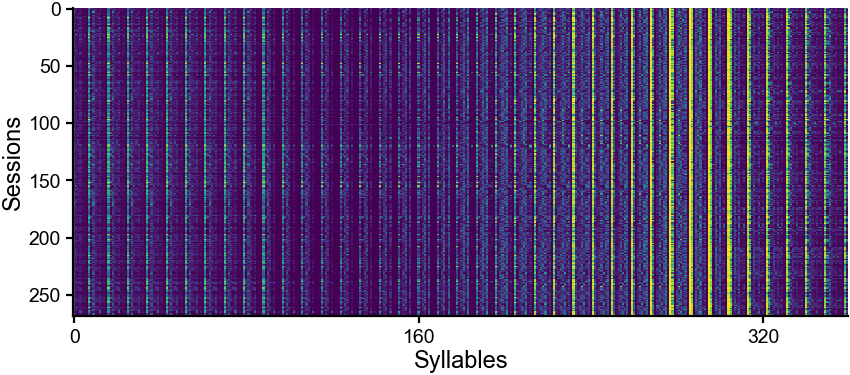

In [10]:
plt.figure(figsize=(10, 4))
plt.imshow(np.array(session_syllables), aspect='auto', cmap='viridis', interpolation='none')
plt.xticks(np.arange(0, session_syllables.shape[1], 160), np.arange(0, session_syllables.shape[1], 160))
plt.xlabel('Syllables')
plt.ylabel('Sessions')

# Dimensionality reduction

In [11]:
all_features = session_syllables.copy()

30 components explain 0.95 of total variance


Text(0.5, 1.0, 'Explained Variance by PCA')

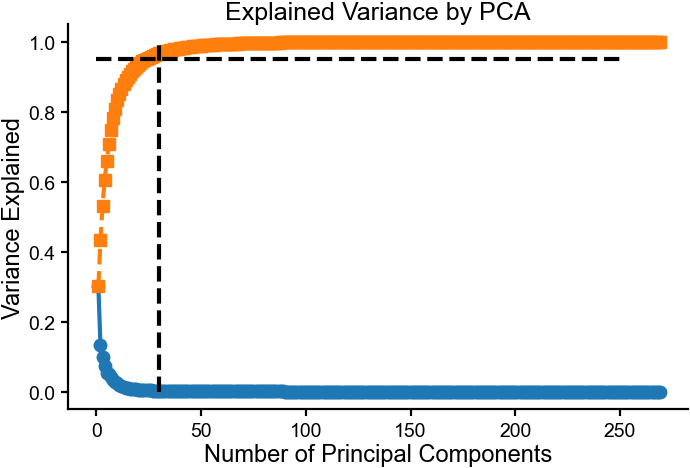

In [12]:
# PCA
n_components = np.min([np.shape(np.array(all_features))[0], np.shape(np.array(all_features))[1]])
# Step 1: Reduce dimensions with PCA
pca = PCA(n_components)  # Reduce to 50 dimensions
scaler = StandardScaler()
# standardized_X = scaler.fit_transform(np.array(all_features))
# X_pca = pca.fit_transform(standardized_X)
X_pca = pca.fit_transform(np.array(all_features))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
threshold = 0.95
min_components = np.where(cumulative_variance>threshold)[0][0]
min_components = 30
print(str(min_components) + ' components explain ' + str(threshold) +' of total variance')

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
plt.hlines(threshold, 0, 250, 'black', 'dashed')
plt.vlines(min_components, 0, 1, 'black', 'dashed')
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA")

In [13]:
# min_components = 10

In [14]:
mat = np.array(session_syllables.copy())
mat = np.array(X_pca[:, :min_components])

scaler = StandardScaler()
norm_pop = scaler.fit_transform(mat.copy())

# LDA

In [15]:
mapping = pd.DataFrame(np.array(design_df[['mouse_name', 'session']].drop_duplicates()), columns=['mouse_name', 'session'])
df_with_sessions = session_syllables.reset_index()
mouse_names = df_with_sessions.merge(mapping, on=['session'])['mouse_name']
df = df_with_sessions.merge(mapping, on=['session'])

In [16]:
n_per_mouse = 3
lda_components = 30
lda_components = np.min([min_components, len(mouse_names.unique())-1])
# lda_components = 30
n_repeats = 10

final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Store repeat results
true_scores_all = []
shuffle_scores_all = []

for repeat in range(n_repeats):
    scores_true = []
    scores_shuff = []

    # Subsample balanced sessions for training in each fold
    for test_idx in range(n_samples):
        X_test = X[test_idx:test_idx+1]
        y_test = y[test_idx:test_idx+1]
        train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
        X_train_full = X[train_idx]
        y_train_full = y[train_idx]

        # --- balanced subsampling for training ---
        # the cap is a MAXIMUM contribution, not a minimum requirement -- see the
        # header cell. Every mouse stays a class, sparse ones contribute what they have.
        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            take = min(n_per_mouse - 1, len(m_idx))
            if take > 0:
                balanced_idx.extend(rng.choice(m_idx, take, replace=False))
        balanced_idx = np.array(balanced_idx)
        assert y_test[0] in y_train_full[balanced_idx], (
            "the held-out mouse is not a training class -- this fold is unanswerable")
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        # --- true labels run ---
        lda = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
            n_components=lda_components)
        lda.fit(X_train, y_train)
        scores_true.append(lda.score(X_test, y_test))

        # --- shuffled labels run ---
        y_train_shuff = y_train.copy()
        rng.shuffle(y_train_shuff)
        lda_shuff = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train_shuff))) / len(np.unique(y_train_shuff)),
            n_components=lda_components)
        lda_shuff.fit(X_train, y_train_shuff)
        scores_shuff.append(lda_shuff.score(X_test, y_test))
        
    # store average score for this repeat
    true_scores_all.append(np.mean(scores_true))
    shuffle_scores_all.append(np.mean(scores_shuff))

print("True labels mean ± std:", np.mean(true_scores_all), np.std(true_scores_all))
print("Shuffled labels mean ± std:", np.mean(shuffle_scores_all), np.std(shuffle_scores_all))

True labels mean ± std: 0.7576208178438661 0.020415658316350893
Shuffled labels mean ± std: 0.016728624535315987 0.0071022205109824545


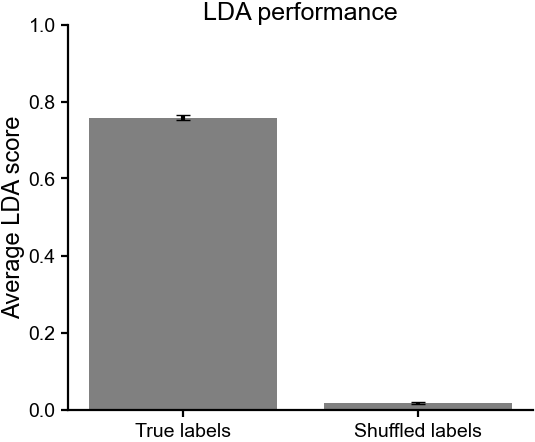

In [17]:
# Convert to arrays for convenience
true_scores = np.array(true_scores_all)
shuffle_scores = np.array(shuffle_scores_all)

# Compute means and standard deviations
means = [np.mean(true_scores), np.mean(shuffle_scores)]
stds  = [np.std(true_scores), np.std(shuffle_scores)]
std_errs = [np.std(true_scores)/np.sqrt(len(true_scores)), 
            np.std(shuffle_scores)/np.sqrt(len(shuffle_scores))]

labels = ['True labels', 'Shuffled labels']

# Create bar plot with error bars
plt.figure(figsize=(6,5))
plt.bar(labels, means, yerr=std_errs, color='grey', capsize=5) #, color=['skyblue','lightcoral']
plt.ylabel('Average LDA score')
plt.title('LDA performance')
plt.ylim(0,1)
# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'lda_score.svg', format='svg', bbox_inches='tight')
plt.show()

### Rerun for analyses

In [18]:
n_per_mouse = 3
lda_components = 30
lda_components = min_components

# final_matrix = np.array(norm_array)
final_matrix = np.array(norm_pop)
# final_matrix = np.array(mat)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Subsample balanced sessions for training in each fold
for test_idx in range(n_samples):

    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx:test_idx+1]

    train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
    X_train_full = X[train_idx]
    y_train_full = y[train_idx]

    # --- balanced subsampling for training ---
    # cap = maximum contribution (header cell). The original guard was worse here:
    # with n_per_mouse=3 the 20 three-session mice have 2 left after leave-one-out,
    # below the cap, so they were dropped in EVERY fold -- mouse_means came back NaN
    # and they vanished from the LD1 analysis silently.
    balanced_idx = []
    for m in np.unique(y_train_full):
        m_idx = np.where(y_train_full == m)[0]
        take = min(n_per_mouse, len(m_idx))
        if take > 0:
            balanced_idx.extend(rng.choice(m_idx, take, replace=False))

    balanced_idx = np.array(balanced_idx)
    X_train = X_train_full[balanced_idx]
    y_train = y_train_full[balanced_idx]

    X_train = X_train_full
    y_train = y_train_full

# Fit for visualization

In [19]:
final_matrix = np.array(norm_pop)

In [20]:
# --- fit the SAVED embedding ---
# On ALL sessions, not on whatever X_train the loop above left behind. See the header
# cell: that leftover was one arbitrary balanced draw, and because the leading LDA
# eigenvalues are near-tied, different draws rotate LD1/LD2/LD3 among themselves --
# so the saved axis was not reproducible. Fitting on everything is deterministic.
X = final_matrix.copy()
y_embed = pd.factorize(mouse_names)[0]

if EMBED_BALANCED:
    _rng = np.random.default_rng(EMBED_SEED)
    _idx = []
    for m in np.unique(y_embed):
        m_idx = np.where(y_embed == m)[0]
        _idx.extend(_rng.choice(m_idx, min(n_per_mouse - 1, len(m_idx)), replace=False))
    _idx = np.sort(np.array(_idx))
    X_fit, y_fit = X[_idx], y_embed[_idx]
    print(f"embedding fit on ONE balanced draw: {len(_idx)} sessions "
          f"(seed {EMBED_SEED}) -- reproducible, but draw-dependent")
else:
    X_fit, y_fit = X, y_embed
    print(f"embedding fit on ALL {len(X)} sessions, "
          f"{len(np.unique(y_embed))} mice -- deterministic")

_ncls = len(np.unique(y_fit))
lda = LinearDiscriminantAnalysis(priors=np.ones(_ncls) / _ncls,
                                 n_components=min(lda_components, _ncls - 1))
lda.fit(X_fit, y_fit)
final_transformed = lda.transform(X)
print("LDA explained_variance_ratio_ (top 6):",
      np.round(lda.explained_variance_ratio_[:6], 3),
      "\n  near-equal leading values mean those axes are free to rotate among "
      "themselves; treat them as a subspace, not as individual axes")
clustered = pd.DataFrame(final_transformed)
clustered['mouse_name'] = mouse_names
clustered['mouse_number'] = pd.factorize(clustered['mouse_name'])[0]
# clustered['lab'] = lab_id
# clustered['lab_number'] = pd.factorize(clustered['lab'])[0]
# clustered['litter_id'] = litter_id
# clustered['litter_number'] = pd.factorize(clustered['litter_id'])[0]
clustered['session'] = session_syllables.reset_index()['session']

# clustered = clustered.merge(cluster_df[['mouse_name', 'mouse_cluster']].drop_duplicates(), on=['mouse_name'])

embedding fit on ALL 269 sessions, 58 mice -- deterministic
LDA explained_variance_ratio_ (top 6): [0.142 0.119 0.093 0.084 0.073 0.062] 
  near-equal leading values mean those axes are free to rotate among themselves; treat them as a subspace, not as individual axes


In [21]:
len(clustered.mouse_name.unique())

58

### Structural coefficients

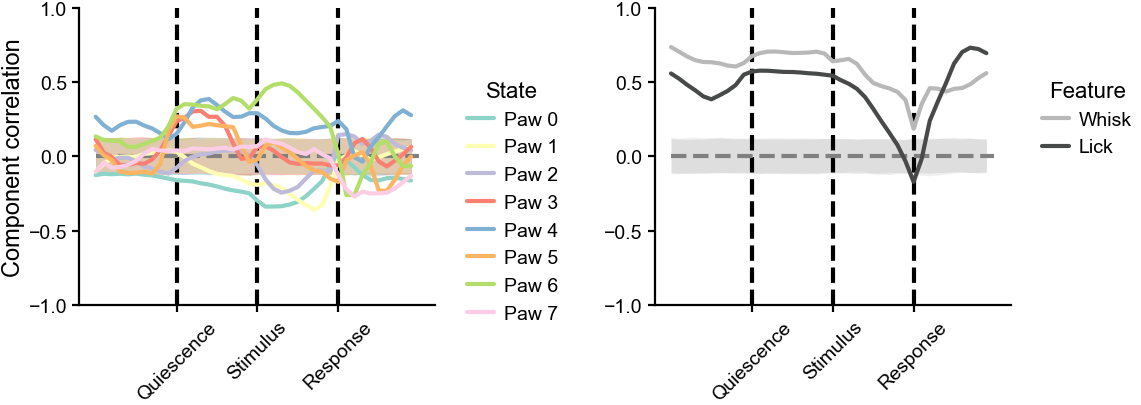

In [22]:
timesteps = 40

# 1. Get the LDA scores for all trials (their position on the LD1 axis)
lda_scores = final_transformed
y_true = lda_scores[:, 0]

n_features_per_step = n_paw_states - 1 + 2
feats = np.array(session_syllables)  # (n_sessions, 360)

def colwise_pearsonr(X, y):
    """Vectorized per-column Pearson r between each column of X and y."""
    Xc = X - X.mean(axis=0, keepdims=True)
    yc = y - y.mean()
    num = Xc.T @ yc
    denom = np.sqrt((Xc**2).sum(axis=0)) * np.sqrt((yc**2).sum())
    return num / denom

# 2. Correlate each original syllable (360 features) with the true LDA scores
struct_coeffs = colwise_pearsonr(feats, y_true)
reshaped_struct = struct_coeffs.reshape(timesteps, n_features_per_step)

paw_importance = reshaped_struct[:, :n_paw_states-1]  # First 7 columns
whisk_importance = reshaped_struct[:, n_paw_states-1] # 8th column
lick_importance = reshaped_struct[:, n_paw_states]  # 9th column

# Paw State 1 (index 1) was dropped from the design matrix as the redundant one-hot
# reference column (binarize() deletes it at every timestep since the 8 paw states
# sum to 1). Reconstruct its per-session, per-timestep value as 1 - the other 7
# paw probabilities, then correlate that reconstructed series with the LDA scores.
feats_reshaped = feats.reshape(-1, timesteps, n_features_per_step)
omitted_paw_state = 1 - feats_reshaped[:, :, :n_paw_states-1].sum(axis=2)  # (n_sessions, timesteps)
omitted_struct_coeffs = colwise_pearsonr(omitted_paw_state, y_true)

# Assemble all 8 paw states in their true order (0..7)
paw_importance_full = np.zeros((timesteps, n_paw_states))
paw_importance_full[:, 0] = paw_importance[:, 0]
paw_importance_full[:, 1] = omitted_struct_coeffs
paw_importance_full[:, 2:] = paw_importance[:, 1:]

# 3. Control: shuffle the LDA assignments (permute which score belongs to which
# session) and recompute the same correlation profiles many times, to get a null
# distribution / 95% CI band at each timestep for every feature.
n_perms = 1000
rng = np.random.default_rng(0)

shuffled_struct = np.zeros((n_perms, timesteps, n_features_per_step))
shuffled_omitted = np.zeros((n_perms, timesteps))
for p in range(n_perms):
    y_shuff = rng.permutation(y_true)
    shuffled_struct[p] = colwise_pearsonr(feats, y_shuff).reshape(timesteps, n_features_per_step)
    shuffled_omitted[p] = colwise_pearsonr(omitted_paw_state, y_shuff)

shuffled_paw = shuffled_struct[:, :, :n_paw_states-1]
shuffled_paw_full = np.zeros((n_perms, timesteps, n_paw_states))
shuffled_paw_full[:, :, 0] = shuffled_paw[:, :, 0]
shuffled_paw_full[:, :, 1] = shuffled_omitted
shuffled_paw_full[:, :, 2:] = shuffled_paw[:, :, 1:]

paw_ci_lo, paw_ci_hi = np.percentile(shuffled_paw_full, [2.5, 97.5], axis=0)
whisk_ci_lo, whisk_ci_hi = np.percentile(shuffled_struct[:, :, n_paw_states-1], [2.5, 97.5], axis=0)
lick_ci_lo, lick_ci_hi = np.percentile(shuffled_struct[:, :, n_paw_states], [2.5, 97.5], axis=0)

# 4. Plot - paw states and whisk/lick as separate panels
time_axis = np.arange(timesteps)
palette = sns.color_palette('Set3', n_paw_states)

fig, (ax_paw, ax_wl) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax in (ax_paw, ax_wl):
    ax.vlines(10, -1, 1, color='k', linestyle='--')
    ax.vlines(20, -1, 1, color='k', linestyle='--')
    ax.vlines(30, -1, 1, color='k', linestyle='--')
    ax.hlines(0, 0, timesteps, color='grey', linestyle='--')
    ax.set_xticks([10, 20, 30])
    ax.set_xticklabels(['Quiescence', 'Stimulus', 'Response'], rotation=45)

for state in range(n_paw_states):
    ax_paw.fill_between(time_axis, paw_ci_lo[:, state], paw_ci_hi[:, state],
                         color=palette[state], alpha=0.5, linewidth=0)
    ax_paw.plot(time_axis, paw_importance_full[:, state], label=f'Paw {state}',
                color=palette[state], alpha=1, lw=3)

ax_paw.set_ylim([-1, 1])
# ax_paw.set_title('Paw states - LDA 1')
ax_paw.set_ylabel('Component correlation')
ax_paw.legend(title='State', bbox_to_anchor=(1.05, .8), loc='upper left')

ax_wl.fill_between(time_axis, whisk_ci_lo, whisk_ci_hi, color="#b8b8b8", alpha=0.2, linewidth=0)
ax_wl.plot(time_axis, whisk_importance, color="#b8b8b8", label='Whisk', lw=3)

ax_wl.fill_between(time_axis, lick_ci_lo, lick_ci_hi, color="#484949", alpha=0.1, linewidth=0)
ax_wl.plot(time_axis, lick_importance, color="#484949", label='Lick', lw=3)

ax_wl.set_ylim([-1, 1])
# ax_wl.set_title('Whisk & Lick - LDA 1')
ax_wl.legend(title='Feature', bbox_to_anchor=(1.05, .8), loc='upper left')

plt.tight_layout()
# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'feature_importances_lda.svg', format='svg', bbox_inches='tight')
plt.show()

# Save data

In [23]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
current_date = datetime.now().strftime('%d-%m-%Y')
filename = f"mouse_LDA_5_bins_cut{min_components}_{current_date}"
clustered['binned1'] = pd.cut(clustered[0], 5)
clustered['binned2'] = pd.cut(clustered[1], 5)
clustered['binned3'] = pd.cut(clustered[2], 5)
clustered['binned4'] = pd.cut(clustered[3], 5)
clustered['binned5'] = pd.cut(clustered[4], 5)
import pickle
# pickle.dump(open(results_df, 'wb'), filename)
clustered.to_pickle(data_path+filename)  

In [24]:
# --- Save proficiency correlation profiles for ALL LDA components -----------
# Per-timestep correlation of each behavioural feature with each LDA score,
# reshaped to (40 timesteps, components) -- same computation as the structural-
# coefficients plot above, looped over every LDA component. Consumed by
# whisk_state_timepoints:  r_prof = pd.read_parquet(file)[variable]  ("whisk"/"lick").
# Component index is 0-based, so LDA 1 -> component0 file.
from scipy.stats import pearsonr
_feats = np.array(session_syllables)
_cols = [f"paw_{s}" for s in range(n_paw_states - 1)] + ["whisk", "lick"]
for _comp in range(final_transformed.shape[1]):
    _sc = np.array([pearsonr(_feats[:, i], final_transformed[:, _comp])[0]
                    for i in range(_feats.shape[1])])
    _prof = pd.DataFrame(_sc.reshape(40, n_paw_states - 1 + 2), columns=_cols)
    # _prof.to_parquet(data_path + f"lda_corr_profile_component{_comp}_{current_date}")
print(f"Saved {final_transformed.shape[1]} LDA correlation profiles -> "
      f"{data_path}lda_corr_profile_component*_{current_date}")

Saved 30 LDA correlation profiles -> /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/clustering/lda_corr_profile_component*_08-09-2026


In [25]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = "mouse_LDA_quadrants"
# clustered.loc[(clustered[0]<0) & (clustered[1]<0), 'quadrant'] = 3
# clustered.loc[(clustered[0]>0) & (clustered[1]>0), 'quadrant'] = 1
# clustered.loc[(clustered[0]>0) & (clustered[1]<0), 'quadrant'] = 2
# clustered.loc[(clustered[0]<0) & (clustered[1]>0), 'quadrant'] = 4
# import pickle
# # pickle.dump(open(results_df, 'wb'), filename)
# clustered.to_pickle(data_path+filename) 

In [26]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = "mouse_LDA_quadrants"

# clustered['binned1'] = pd.cut(clustered[0], 3)
# clustered['binned2'] = pd.cut(clustered[1], 3)
# clustered['binned3'] = pd.cut(clustered[2], 3)
# # clustered['binned4'] = pd.cut(clustered[3], 5)
# # clustered['binned5'] = pd.cut(clustered[4], 5)
# import pickle
# # pickle.dump(open(results_df, 'wb'), filename)
# # clustered.to_pickle(data_path+filename)  

wrote figures/lda12_mice_poster_08-09-2026.png, figures/lda12_mice_poster_08-09-2026.svg


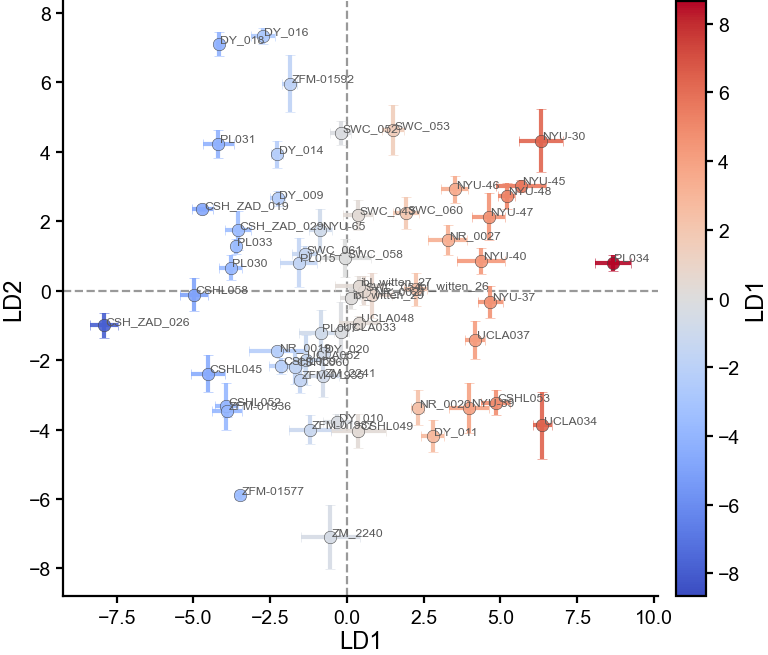

In [27]:
"""
MICE IN THE LDA SPACE -- one point per mouse, coloured by its LD1 position.
Colour, panel size, type and export all come from paper_style, so this figure
matches every other LD1 figure in the paper. ps.use('paper') in the header cell
re-renders it at journal size with no other edit.
"""
SHOW_LABELS = True        # mouse names next to the points; crowded at 58 mice
SEM_PER_MOUSE = True     # False keeps the original fixed /sqrt(4);
                          # True uses each mouse's own session count (see below)

df_lda = clustered.copy()
grouped = df_lda.groupby(['mouse_name', 'mouse_number'])
mouse_means = grouped[[0, 1, 2]].mean()
if SEM_PER_MOUSE:
    # NOTE this changes the error bars: the original divides every mouse's SD by
    # sqrt(4) regardless of how many sessions it actually has (3 to 16 here).
    mouse_stds = grouped[[0, 1, 2]].std().div(np.sqrt(grouped.size()), axis=0)
else:
    mouse_stds = grouped[[0, 1, 2]].std() / np.sqrt(4)

ld1 = mouse_means[0].values
colors = ps.ld1_colors(ld1)          # coolwarm, symmetric about 0

fig, ax = ps.figure('single', scale=1.4)
for (mouse, cvec) in zip(mouse_means.index, colors):
    mean_vals = mouse_means.loc[mouse]
    std_vals = mouse_stds.loc[mouse]
    ax.errorbar(mean_vals[0], mean_vals[1],
                xerr=std_vals[0], yerr=std_vals[1],
                fmt='o', color=cvec, ecolor=cvec, alpha=0.9,
                markeredgecolor='0.25', markeredgewidth=0.4, zorder=2)
    if SHOW_LABELS:
        ax.text(mean_vals[0] + 0.05, mean_vals[1] + 0.05, str(mouse[0]),
                fontsize=plt.rcParams['font.size'] * 0.55, color='0.35', zorder=3)

ax.axvline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
ax.axhline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
# SQUARE PLOTTING AREA, not a square figure: set_box_aspect fixes the ratio of the
# AXES rectangle itself, so the colorbar and labels take their space outside it and
# the data area stays square whatever the figure size or mode.
ax.set_box_aspect(1)
# If instead you want one LD unit to be the same length on both axes -- which is the
# honest choice when distances in LDA space are being read -- use equal DATA aspect
# and symmetric limits; the box then comes out square as a consequence:
#     lim = np.nanmax(np.abs(np.r_[ax.get_xlim(), ax.get_ylim()]))
#     ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')

ps.ld1_colorbar(ax, label='LD1', values=ld1, fraction=0.046, pad=0.02)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
fig.tight_layout()
ps.savefig(fig, 'lda12_mice', svg=True)   # PNG + vector master
plt.show()


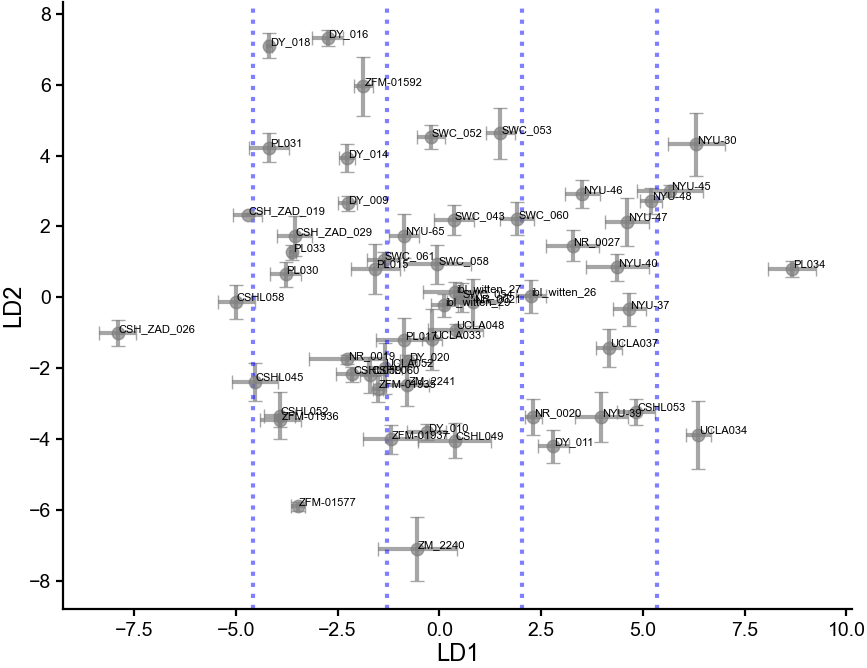

In [28]:
plt.figure(figsize=(9,7))
colors = sns.color_palette('tab20') + sns.color_palette('Set3') + sns.color_palette('Pastel1')
colors = colors[:60]

plt.rc('font', size=12, weight='normal')

for mouse in mouse_means.index:
    mean_vals = mouse_means.loc[mouse]
    std_vals = mouse_stds.loc[mouse]
    x = mean_vals[0]
    y = mean_vals[1]
    plt.errorbar(
        x, y,
        xerr=std_vals[0], yerr=std_vals[1],
        fmt='o', capsize=5,
        color='grey', alpha=0.7)  # colors[mouse[4]]

    # Add label next to point
    plt.text(
        x + 0.02, y + 0.02,          # small offset so text isn't on top of the dot
        str(mouse[0]),               # mouse name
        fontsize=8)

# plt.vlines(0, -8, 8, color='grey', linestyle='--')
# plt.hlines(0, -6, 10, color='grey', linestyle='--')

# Add bin edges for 5 bins on each axis
x_vals = mouse_means.iloc[:, 0]
y_vals = mouse_means.iloc[:, 1]

x_bins = pd.cut(x_vals, bins=5, retbins=True)[1]
y_bins = pd.cut(y_vals, bins=5, retbins=True)[1]

for xb in x_bins[1:-1]:  # skip outermost edges
    plt.axvline(xb, color='blue', linestyle=':', alpha=0.5)

# for yb in y_bins[1:-1]:
#     plt.axhline(yb, color='red', linestyle=':', alpha=0.5)

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.grid(False)
plt.tight_layout()

In [29]:
np.sum(lda.explained_variance_ratio_)

1.0000000000000002

Text(0.5, 0, 'LDA components')

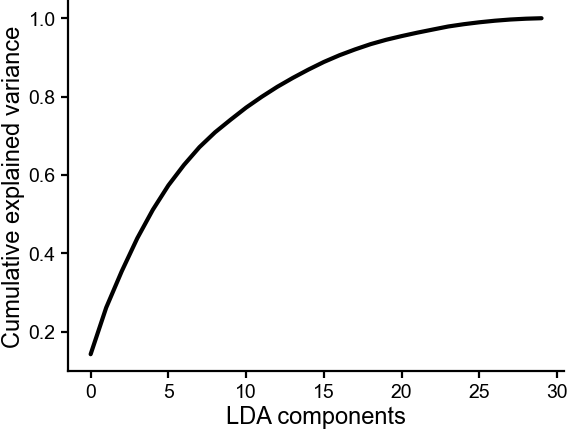

In [30]:
plt.plot(np.cumsum(lda.explained_variance_ratio_), color='black')
plt.ylabel('Cumulative explained variance')
plt.xlabel('LDA components')

# Train/ test mouse correlations

In [31]:
n_per_mouse = 3
lda_components = min_components

lda_to_check = 0

# final_matrix = np.array(norm_array)
# final_matrix = np.array(mat)
final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]

n_samples = X.shape[0]
mouse_means = np.zeros(len(y)) * np.nan
ld_held_out = np.zeros(len(y)) * np.nan

# Subsample balanced sessions for training in each fold
for test_idx in range(n_samples):
    
    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx:test_idx+1]

    train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
    X_train_full = X[train_idx]
    y_train_full = y[train_idx]

    # --- balanced subsampling for training ---
    # cap = maximum contribution (header cell). The original guard was worse here:
    # with n_per_mouse=3 the 20 three-session mice have 2 left after leave-one-out,
    # below the cap, so they were dropped in EVERY fold -- mouse_means came back NaN
    # and they vanished from the LD1 analysis silently.
    balanced_idx = []
    for m in np.unique(y_train_full):
        m_idx = np.where(y_train_full == m)[0]
        take = min(n_per_mouse, len(m_idx))
        if take > 0:
            balanced_idx.extend(rng.choice(m_idx, take, replace=False))

    balanced_idx = np.array(balanced_idx)
    X_train = X_train_full[balanced_idx]
    y_train = y_train_full[balanced_idx]

    # --- true labels run ---
    lda = LinearDiscriminantAnalysis(
        priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
        n_components=lda_components)
    
    lda.fit(X_train, y_train)
    transformed = lda.transform(X_train)
    mouse_means[test_idx] = np.mean(transformed[y_train == y_test, lda_to_check])  # LD1
    ld_held_out[test_idx] = lda.transform(X_test)[0][lda_to_check]  # if multiple sessions, take mean

Text(0.05, 0.95, 'r = 0.741, p = 4.47e-48')

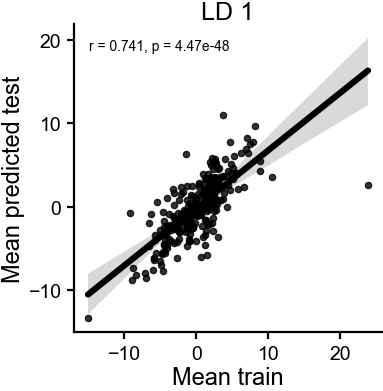

In [32]:
corr_df = pd.DataFrame(columns=['mean_train', 'transformed_test'])
corr_df['mean_train'] = mouse_means
corr_df['transformed_test'] = ld_held_out
corr_df = corr_df.dropna()

fig, ax = ps.figure('single', scale=.8)
ax.set_box_aspect(1)              # the AXES rectangle is square
sns.regplot(x=np.array(corr_df['mean_train']).astype(float), 
            y=corr_df['transformed_test'].astype(float), scatter_kws={'s': 20}, color='black', ci=95) 
plt.xlabel('Mean train')
plt.ylabel('Mean predicted test')
plt.title('LD '+str(lda_to_check+1))

res = stats.pearsonr(np.array(corr_df['mean_train']).astype(float), corr_df['transformed_test'].astype(float))
plt.text(0.05, 0.95, f'r = {res.statistic:.3f}, p = {res.pvalue:.2e}',
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'train_test_corr.svg', format='svg', bbox_inches='tight')

# Correlate with training time

In [33]:
path = prefix + 'representation_learning_variability/learning_prediction/'
# path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/training_data/'
# training_time = pd.read_parquet(path+'training_time_23-09-2025')
# training_time = pd.read_parquet(data_path+'training_time_23-03-2026')
training_time = pd.read_parquet(path+'training_time_27-04-2026')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/learning_prediction/training_time_27-04-2026'

In [ ]:
var_name = 'training_days'
learning_df = clustered.merge(training_time, on='mouse_name')
learning_df['log_training'] = np.log(learning_df[var_name])

Text(0, 0.5, 'LDA component 2')

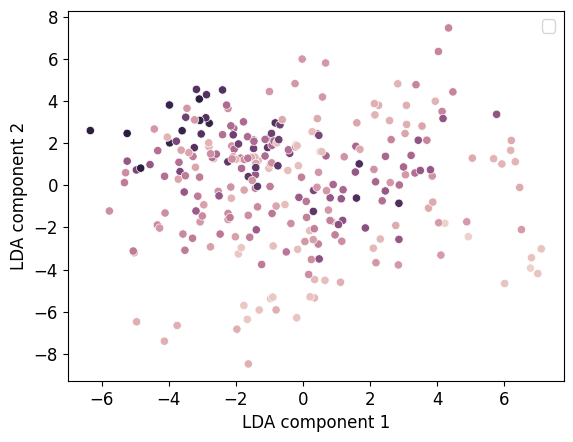

In [ ]:
sns.scatterplot(x=0, y=1, hue=var_name, data=learning_df)
# plt.scatter(archetypes.T[0], archetypes.T[1], color='black', s=1)
# plt.plot(np.concatenate([archetypes.T[0], [archetypes.T[0][0]]]), np.concatenate([archetypes.T[1], [archetypes.T[1][0]]]), color='grey')
plt.legend('')
plt.xlabel('LDA component 1')
plt.ylabel('LDA component 2')

PearsonRResult(statistic=np.float64(-0.36694862109990367), pvalue=np.float64(0.00498977418328872))


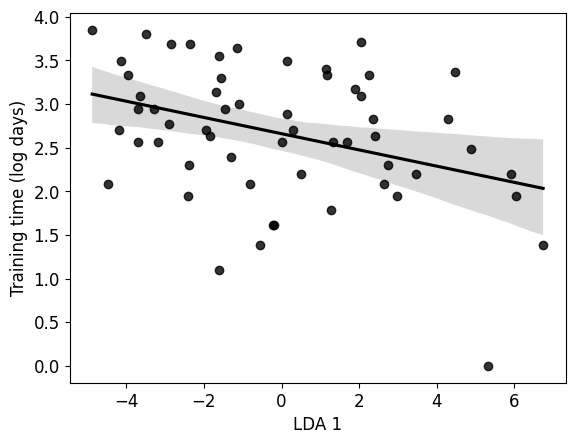

In [ ]:
component = 0
group_df = learning_df.groupby(['mouse_name', var_name])[component].mean().reset_index()

sns.regplot(x=np.array(group_df[component]).astype(float), y=np.log(group_df[var_name]).astype(float), color='black', ci=95) 
plt.xlabel('LDA 1')
plt.ylabel('Training time (log days)')
plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'training_time_corre_lda1.svg', format='svg', bbox_inches='tight')

res = stats.pearsonr(np.array(group_df[component]).astype(float), np.log(group_df[var_name]).astype(float))
print(res)

PearsonRResult(statistic=np.float64(-0.30322341509923745), pvalue=np.float64(4.623255776530248e-07))


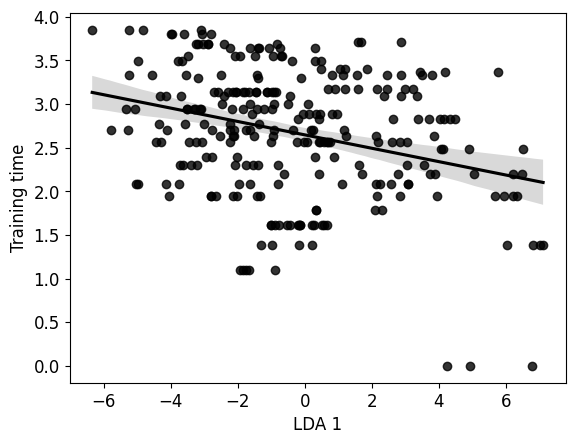

In [ ]:
component = 0
group_df = learning_df.groupby(['mouse_name', var_name])[component].mean().reset_index()

sns.regplot(x=np.array(learning_df[component]).astype(float), y=np.log(learning_df[var_name]).astype(float), 
            color='black',ci=95) 
plt.xlabel('LDA 1')
plt.ylabel('Training time')

res = stats.pearsonr(np.array(learning_df[component]).astype(float), np.log(learning_df[var_name]).astype(float))
print(res)